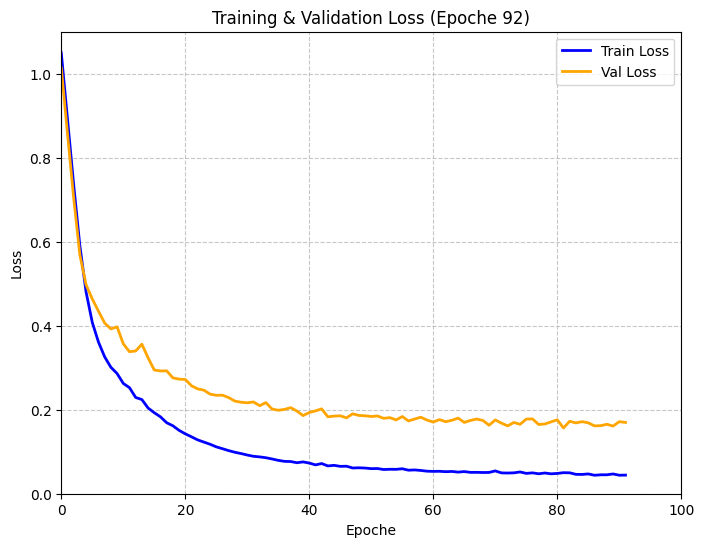


--- Early Stopping ausgelöst in Epoche 92 ---
Bester Validation Loss war: 0.1567

Beste Modellgewichte wurden wiederhergestellt.
Testgenauigkeit:  1.0


['Models/scaler_NextStep5.pkl']

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler # NEU
import joblib
from torch.utils.data import TensorDataset, DataLoader
import copy
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# 1. Laden des Datensatzes
df = pd.read_csv('Datasets/Iris.csv')

# 2. Features (X) und Target (y) trennen
X = df.drop('species', axis=1).values
y = df['species'].values

# LabelEncoder sortiert die gefundenen Text-Kategorien standardmäßig alphabetisch
le = LabelEncoder()
y = le.fit_transform(y)
 
# 3. Aufteilen des Datensatzes (Train / Val / Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

# Feature Scaling ---
# Für neuronale Netze ist Skalierung essenziell für die Konvergenz. Gängige Methoden:
# 1. StandardScaler (Standardisierung): Mittelwert = 0, Standardabweichung = 1 (Standard für NNs)
# 2. MinMaxScaler (Normalisierung): Skaliert Werte starr in einen Bereich (meist 0 bis 1)
# 3. RobustScaler: Nutzt Median und Quartile, sehr robust gegenüber Ausreißern (Outliers)
scaler = StandardScaler()

# WICHTIG (Vermeidung von Data Leakage): 'fit_transform' NUR auf Trainingsdaten anwenden!
# Der Scaler lernt hier den Mittelwert und die Varianz der Trainingsdaten.
X_train = scaler.fit_transform(X_train)

# Auf Validierungs- und Testdaten NUR 'transform' anwenden!
# Sie werden mit den Parametern skaliert, die aus den Trainingsdaten gelernt wurden.
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
# -----------------------------------------
 
# 4. Umwandeln der skalierten Daten in PyTorch-Tensoren
X_train = torch.from_numpy(X_train).float()
X_test  = torch.from_numpy(X_test).float()
y_train = torch.from_numpy(y_train).long()
y_test  = torch.from_numpy(y_test).long()
X_val   = torch.from_numpy(X_val).float()
y_val   = torch.from_numpy(y_val).long()

# Erstellen eines TensorDatasets und DataLoaders - Kombinieren von Features und Labels zu einem Dataset
train_dataset = TensorDataset(X_train, y_train)
# Erstellen des DataLoaders für das Training
batch_size = 12
# shuffle=True sorgt dafür, dass die Daten in jeder Epoche gemischt werden
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Definieren des neuronalen Netzes als Sequential-Modell
net = nn.Sequential(
    nn.Linear(4, 5),   # Eingabeschicht (4 Merkmale) -> Versteckte Schicht (10 Neuronen)
    nn.ReLU(),           # Aktivierungsfunktion: ReLU
    nn.Linear(5, 3)     # Versteckte Schicht (10 Neuronen) -> Ausgabeschicht (3 Klassen)
)
 
# Definieren des Verlustkriteriums und des Optimierers
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(net.parameters(), lr=0.01)

# --- Setup für Early Stopping ---
patience = 10               # Wie viele Epochen warten wir ohne Verbesserung?
patience_counter = 0        # Zähler für die Epochen ohne Verbesserung
best_val_loss = float('inf') # Startwert für den besten Loss (unendlich hoch)
best_model_weights = None   # Hier speichern wir das beste Modell

# Listen zum Speichern der Historie (ideal für spätere Plots, z.B. mit matplotlib)
# Listen zum Speichern der Historie
history = {'train_loss': [], 'val_loss': []}

# Setup der Figur VOR der Schleife
fig, ax = plt.subplots(figsize=(8, 6))

# Trainieren des neuronalen Netzes
net.train()

for epoch in range(100):
    net.train()
    kumulierter_train_loss = 0.0

    for batch_data in train_loader: 
        batch_X = batch_data[0]
        batch_y = batch_data[1]
        optimizer.zero_grad()
        outputs = net(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        kumulierter_train_loss += loss.item()
    
    durchschnittlicher_train_loss = kumulierter_train_loss / len(train_loader)
    history['train_loss'].append(durchschnittlicher_train_loss)

    # Validierung
    net.eval()
    with torch.no_grad():
        val_out  = net(X_val)
        val_loss = criterion(val_out, y_val).item() # .item() hinzugefügt für sauberen Float
    
    history['val_loss'].append(val_loss)
    
    # --- Live Plotting in Jupyter ---
    ax.clear() # Löscht die alten Linien im Plot-Objekt
    
    ax.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
    ax.plot(history['val_loss'],   label='Val Loss', color='orange', linewidth=2)
    
    ax.set_xlabel('Epoche')
    ax.set_ylabel('Loss')
    ax.set_title(f'Training & Validation Loss (Epoche {epoch+1})')
    ax.set_xlim(0, 100) 
    ax.set_ylim(bottom=0) # Lässt Matplotlib das obere Limit automatisch anpassen!
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Der Jupyter-Magic-Trick:
    clear_output(wait=True) # Löscht den alten Output der Zelle (wait=True verhindert Flackern)
    display(fig)            # Zeichnet die aktualisierte Figur
    # --------------------------------
    
    # --- Early Stopping Logik ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0 
        best_model_weights = copy.deepcopy(net.state_dict())
    else:
        patience_counter += 1 
        
    if patience_counter >= patience:
        print(f"\n--- Early Stopping ausgelöst in Epoche {epoch+1} ---")
        print(f"Bester Validation Loss war: {best_val_loss:.4f}")
        break

# Am Ende der Schleife den interaktiven Plot schließen, damit er nicht doppelt auftaucht
plt.close(fig) 

# --- Modell wiederherstellen ---
net.load_state_dict(best_model_weights)
print("\nBeste Modellgewichte wurden wiederhergestellt.")

# Auswerten des neuronalen Netzes auf den Testdaten
net.eval()
with torch.no_grad():
    outputs = net(X_test)
    _, predicted = torch.max(outputs, 1)
    accuracy = accuracy_score(y_test, predicted)
    print('Testgenauigkeit: ', accuracy)
 
# Abspeichern des trainierten Netzes
torch.save(net.state_dict(), 'Models/iris_net_NextStep5.pth')
joblib.dump(le, 'Models/label_encoder_NextStep5.pkl')
joblib.dump(scaler, 'Models/scaler_NextStep5.pkl')

In [ ]:
# Wiederladen des State-Dicts
import torch
import torch.nn as nn

net.load_state_dict(torch.load('Models/iris_net_NextStep5.pth', map_location=torch.device('cpu')))
le = joblib.load('Models/label_encoder_NextStep5.pkl')
scaler = joblib.load('Models/scaler_NextStep5.pkl')

net = nn.Sequential(
    nn.Linear(4, 5),    # Eingabeschicht (4 Merkmale) -> Versteckte Schicht (10 Neuronen)
    nn.ReLU(),          # Aktivierungsfunktion: ReLU
    nn.Linear(5, 3)     # Versteckte Schicht (10 Neuronen) -> Ausgabeschicht (3 Klassen)
)
for k, v in net.named_parameters():
    print(k,v)
net.eval()

In [ ]:
# Vorhersage mit dem trainierten Netz

# Eingabe der vier Merkmale
print("Geben Sie die vier Merkmale ein:")
sepal_length = float(input("Sepal-Länge (cm): "))
sepal_width = float(input("Sepal-Breite (cm): "))
petal_length = float(input("Petal-Länge (cm): "))
petal_width = float(input("Petal-Breite (cm): "))

# Skalierung der Eingabewerte
import numpy as np
eingabe = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
eingabe_skaliert = scaler.transform(eingabe)

# Erstellen eines Tensors aus den Eingabewerten
inputs = torch.tensor(eingabe_skaliert, dtype=torch.float32)

# Vorhersage treffen
with torch.no_grad():
    outputs = net(inputs)
    _, predicted = torch.max(outputs, 1)

# Ausgabe der Klassifizierungsaussage
print("Klasse: ", le.inverse_transform([predicted.item()])[0])

In [ ]:
# aus dem obigen Skript wird inputs übernommen, 
# die Vorhersagen werden als Wahrscheinlichkeiten ausgegeben

import torch.nn.functional as F

# Vorhersage des Netzes
with torch.no_grad():
    output = net(inputs)
    _, max_index = torch.max(output, 1)
    print("Vorhergesagte Klasse:", max_index.item())

# Klassenwahrscheinlichkeiten berechnen
probabilities = F.softmax(output, dim=1)
print("Klassenwahrscheinlichkeiten:", probabilities.numpy()[0])